# Train two STEPP-style autoencoders on OUR OWN dataset

This notebook takes our own recorded sequences (Unitree Go2 + ZED camera) and trains **two
brand-new autoencoders from scratch** — one on **DINOv2** features and one on **DINOv3**
features. Nothing is reused from the STEPP authors' weights; both models start from random
numbers and learn only from our own robot's driving experience.

The steps, for each backbone, are:

1. **Project the future path** onto every image (green ribbon = ground the robot walked over).
2. **Cut the image into SLIC superpixels** and keep the ones the path covers.
3. **Run the backbone** and average one 384-number feature vector per kept superpixel.
4. **Train an autoencoder** to rebuild those vectors. Reconstruction error later becomes the
   traversability cost.

**Which sequences are used.** Sequence `00001` is skipped because it was only a test run, and
`00008` is skipped because the robot barely moved in it (0.16 m over 38 frames). In sequence
`00009` the first few frames are dropped, because the robot stood still at the start and the
odometry jumped while stationary — section 4 shows this.

The code is written to be easy to follow: small named functions, plain loops, printed progress.

## 1. Settings

In [1]:
from pathlib import Path

DATA_ROOT = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/Own_dataset')
OUT_DIR   = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/own_outputs')
MODEL_DIR = OUT_DIR / 'models'
FEAT_DIR  = OUT_DIR / 'features'
MODEL_DIR.mkdir(parents=True, exist_ok=True)
FEAT_DIR.mkdir(parents=True, exist_ok=True)

# where the DINOv3 code and weights live
DINOV3_REPO    = Path('C:/Users/jthre/.cache/torch/hub/facebookresearch_dinov3_main')
DINOV3_WEIGHTS = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/DinoV3_vits16/dinov3_vits16_pretrain_lvd1689m-08c60483.pth')

# ---- which sequences to use ----
EXCLUDE_SEQUENCES = [
    '00001',   # test run only
    '00008',   # robot barely moved (0.16 m over 38 frames) -> no usable path
]

# drop the first N images of a sequence (odometry was still settling)
SKIP_FIRST_FRAMES = {
    '00009': 8,    # robot took a long time to start moving
}

# ---- path-projection settings (same as project_own_dataset.ipynb) ----
FUTURE_STEPS    = 50      # how many future poses form the path
MIN_MOVE_M      = 0.10    # skip frames where the robot moved less than 10 cm
MIN_Z           = 0.5     # ignore path points closer than 0.5 m / behind the camera
GROUND_OFFSET_M = 0.35    # camera height above the ground (Go2-sized robot)
ROBOT_WIDTH_M   = 0.40    # width of the path ribbon

# ---- SLIC settings (same everywhere in this project) ----
N_SEGMENTS  = 400
COMPACTNESS = 15

# ---- autoencoder + training settings (same shape as STEPP's "big" network) ----
HIDDEN_SIZES  = [256, 128, 64, 32, 64, 128, 256]   # 384 -> ... -> 384
BATCH_SIZE    = 256
LEARNING_RATE = 0.001
MAX_EPOCHS    = 200
PATIENCE      = 15        # stop when validation loss stops improving
VAL_SPLIT     = 0.2

# ---- speed control ----
FRAME_STRIDE = 1          # 1 = use every frame. Set to 2 or 3 to run faster with less data.
BACKBONES    = ['dinov2', 'dinov3']

# find the sequences we will actually use
all_sequences = sorted(d.name for d in DATA_ROOT.iterdir() if d.is_dir())
SEQUENCES = [s for s in all_sequences if s not in EXCLUDE_SEQUENCES]

print('all sequences found :', all_sequences)
print('excluded            :', EXCLUDE_SEQUENCES)
print('will train on       :', SEQUENCES)
print('frames skipped at start:', SKIP_FIRST_FRAMES)

all sequences found : ['00001', '00003', '00004', '00005', '00006', '00007', '00008', '00009', '00010']
excluded            : ['00001', '00008']
will train on       : ['00003', '00004', '00005', '00006', '00007', '00009', '00010']
frames skipped at start: {'00009': 8}


## 2. Imports and the two backbones

In [2]:
import sys, json, time
import warnings; warnings.filterwarnings('ignore')
import numpy as np
import cv2
import yaml
import torch
import torch.nn as nn
from torchvision import transforms
from scipy.spatial.transform import Rotation
from skimage.segmentation import slic
import matplotlib.pyplot as plt

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print('device:', device)

# both DINOv2 and DINOv3 expect ImageNet-normalised images
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])

def load_backbone(name):
    """Return the model plus the numbers the pipeline needs."""
    if name == 'dinov2':
        model = torch.hub.load('facebookresearch/dinov2', 'dinov2_vits14', verbose=False)
        input_size = 700
        patch = 14           # 700 / 14 = 50
    elif name == 'dinov3':
        sys.path.insert(0, str(DINOV3_REPO))
        from dinov3.hub.backbones import dinov3_vits16
        model = dinov3_vits16(weights=str(DINOV3_WEIGHTS))
        input_size = 704
        patch = 16           # 704 / 16 = 44
    else:
        raise ValueError('unknown backbone: ' + name)

    model = model.to(device).eval()
    for p in model.parameters():
        p.requires_grad = False
    grid = input_size // patch
    print(f'{name}: input {input_size}, patch {patch}, feature grid {grid}x{grid}')
    return model, input_size, patch, grid

def get_feature_map(model, square_rgb, grid):
    """A square RGB picture -> numpy array of shape (grid, grid, 384)."""
    image = torch.from_numpy(square_rgb).permute(2, 0, 1).float() / 255.0
    image = normalize(image).unsqueeze(0).to(device)
    with torch.no_grad():
        tokens = model.get_intermediate_layers(image, n=1)[0][0]
    return tokens.reshape(grid, grid, 384).cpu().numpy()

device: cuda


## 3. Loading one sequence and projecting the future path

This is the same maths as `project_own_dataset.ipynb`, wrapped into one function so we can
call it for every sequence.

In [3]:
def load_sequence(seq):
    """Read one sequence and return everything needed to project paths."""
    seq_dir = DATA_ROOT / seq
    image_paths = sorted((seq_dir / 'pylon_camera_node').glob('*.jpg'))
    pose_lines = [l for l in (seq_dir / 'poses.txt').read_text().splitlines() if l.strip()]
    assert len(image_paths) == len(pose_lines), f'{seq}: images and poses do not match!'

    # drop the first few frames if this sequence needs it
    skip = SKIP_FIRST_FRAMES.get(seq, 0)
    if skip > 0:
        image_paths = image_paths[skip:]
        pose_lines = pose_lines[skip:]

    # poses.txt: 12 numbers per line = a 3x4 [rotation | position] matrix
    poses = []
    for line in pose_lines:
        T = np.eye(4)
        T[:3, :4] = np.array(line.split(), dtype=np.float64).reshape(3, 4)
        poses.append(T)
    T_world_body = np.stack(poses)

    # camera intrinsics
    fx, fy, cx, cy = np.loadtxt(seq_dir / 'camera_info.txt').ravel()[:4]
    K = np.array([[fx, 0, cx], [0, fy, cy], [0, 0, 1]], dtype=np.float64)

    # camera <-> body mounting transform
    yaml_data = yaml.safe_load((seq_dir / 'transforms.yaml').read_text())
    key = next(k for k in yaml_data if 'os1' in k and 'pylon' in k)
    q, t = yaml_data[key]['q'], yaml_data[key]['t']
    T_yaml = np.eye(4)
    T_yaml[:3, :3] = Rotation.from_quat([q['x'], q['y'], q['z'], q['w']]).as_matrix()
    T_yaml[:3, 3] = [t['x'], t['y'], t['z']]
    T_world_cam = T_world_body @ T_yaml       # direction verified in project_own_dataset.ipynb

    # image size (read from the file rather than assumed)
    first = cv2.imread(str(image_paths[0]))
    height, width = first.shape[:2]

    # drop frames where the robot barely moved
    keep = [0]
    for i in range(1, len(T_world_cam)):
        if np.linalg.norm(T_world_cam[i, :3, 3] - T_world_cam[keep[-1], :3, 3]) >= MIN_MOVE_M:
            keep.append(i)

    return {
        'seq': seq,
        'images': [image_paths[i] for i in keep],
        'T_cam':  T_world_cam[keep],
        'T_body': T_world_body[keep],
        'K': K, 'width': width, 'height': height,
        'n_raw': len(image_paths), 'n_skipped_start': skip,
    }

def path_mask(data, idx):
    """Binary mask of the ground the robot will walk over, seen from frame idx."""
    T_body, T_cam = data['T_body'], data['T_cam']
    width, height, K = data['width'], data['height'], data['K']
    D = np.zeros(5)

    # 1) collect the future ground points (centre, left edge, right edge) in world coordinates
    left_edge, right_edge = [], []
    for j in range(idx + 1, min(idx + 1 + FUTURE_STEPS, len(T_body))):
        position = T_body[j][:3, 3]
        forward = T_body[j][:3, 0].copy()
        forward[2] = 0.0
        length = np.linalg.norm(forward)
        if length < 1e-6:
            continue
        forward = forward / length
        left = np.array([-forward[1], forward[0], 0.0])
        ground = position - np.array([0.0, 0.0, GROUND_OFFSET_M])
        left_edge.append(ground + 0.5 * ROBOT_WIDTH_M * left)
        right_edge.append(ground - 0.5 * ROBOT_WIDTH_M * left)

    mask = np.zeros((height, width), np.uint8)
    if len(left_edge) < 2:
        return mask

    # 2) move the points into the camera's view and project them to pixels
    def to_pixels(points):
        world_to_cam = np.linalg.inv(T_cam[idx])
        pts = np.array(points) @ world_to_cam[:3, :3].T + world_to_cam[:3, 3]
        visible = pts[:, 2] > MIN_Z
        pixels = np.full((len(points), 2), np.nan)
        if visible.any():
            proj, _ = cv2.projectPoints(pts[visible].reshape(-1, 1, 3),
                                        np.zeros(3), np.zeros(3), K, D)
            pixels[visible] = proj.reshape(-1, 2)
        return pixels, visible

    pix_left, vis_left = to_pixels(left_edge)
    pix_right, vis_right = to_pixels(right_edge)

    # 3) fill the strip between consecutive left/right points
    for j in range(len(left_edge) - 1):
        if not (vis_left[j] and vis_right[j] and vis_left[j + 1] and vis_right[j + 1]):
            continue
        quad = np.array([pix_left[j], pix_left[j + 1], pix_right[j + 1], pix_right[j]])
        quad = np.clip(quad, -30000, 30000).astype(np.int32)
        if quad[:, 0].max() < 0 or quad[:, 0].min() >= width:
            continue
        if quad[:, 1].max() < 0 or quad[:, 1].min() >= height:
            continue
        cv2.fillPoly(mask, [quad], 1)
    return mask

## 4. Why some frames are dropped

At the very start of a recording the robot often stands still while the odometry is still
settling. During that time the estimated position can *jump* even though the robot is not
moving. Those jumps create nonsense paths, so the affected frames must be removed.

The check below prints the largest position change in the first 30 frames of each sequence. A
healthy start shows tiny numbers; a jump of tens of centimetres while stationary is the
problem we are removing.

In [4]:
print(f"{'seq':<9}{'raw frames':>12}{'max step in first 30':>23}{'jump frames':>16}")
print('-' * 62)
for seq in all_sequences:
    positions = []
    for line in (DATA_ROOT / seq / 'poses.txt').read_text().splitlines():
        if line.strip():
            positions.append(np.array(line.split(), dtype=np.float64).reshape(3, 4)[:, 3])
    positions = np.array(positions)
    steps = np.linalg.norm(np.diff(positions, axis=0), axis=1)
    jump_frames = np.where(steps[:30] > 0.15)[0].tolist()
    flag = ''
    if seq in EXCLUDE_SEQUENCES:
        flag = '  <- excluded'
    elif seq in SKIP_FIRST_FRAMES:
        flag = f'  <- first {SKIP_FIRST_FRAMES[seq]} frames dropped'
    print(f'{seq:<9}{len(positions):>12}{steps[:30].max():>21.3f} m'
          f'{str(jump_frames) if jump_frames else "none":>16}{flag}')

print('\nOnly sequence 00009 shows startup jumps. If the overlays for it still look wrong,')
print('increase SKIP_FIRST_FRAMES[\'00009\'] in section 1 (about 25 clears every jump).')

seq        raw frames   max step in first 30     jump frames
--------------------------------------------------------------
00001             224                0.086 m            none  <- excluded
00003             733                0.000 m            none
00004             835                0.001 m            none
00005             535                0.000 m            none
00006             874                0.000 m            none
00007            1314                0.000 m            none
00008              38                0.017 m            none  <- excluded
00009            1883                0.641 m[2, 17, 20, 21, 23]  <- first 8 frames dropped
00010            1597                0.001 m            none

Only sequence 00009 shows startup jumps. If the overlays for it still look wrong,
increase SKIP_FIRST_FRAMES['00009'] in section 1 (about 25 clears every jump).


In [5]:
# load every sequence we will train on and report how many usable frames each has
sequence_data = {}
print(f"{'seq':<9}{'raw':>8}{'skipped':>10}{'after move filter':>20}")
print('-' * 48)
for seq in SEQUENCES:
    data = load_sequence(seq)
    sequence_data[seq] = data
    print(f"{seq:<9}{data['n_raw'] + data['n_skipped_start']:>8}"
          f"{data['n_skipped_start']:>10}{len(data['images']):>20}")
total_frames = sum(len(d['images']) for d in sequence_data.values())
print('-' * 48)
print(f"{'TOTAL':<9}{'':>8}{'':>10}{total_frames:>20}")

seq           raw   skipped   after move filter
------------------------------------------------
00003         733         0                 266
00004         835         0                 350
00005         535         0                 152
00006         874         0                 397
00007        1314         0                 597
00009        1883         8                 933
00010        1597         0                 836
------------------------------------------------
TOTAL                                      3531


## 5. Turning images into training vectors

For one image: cut it into superpixels, find which ones the path covers, run the backbone, and
average one 384-number vector per covered superpixel. Those vectors are the training data.

Results are cached to disk, so running this notebook a second time is fast.

In [6]:
def features_for_one_image(model, input_size, grid, image_path, mask):
    """One image + its path mask -> array of shape (number of path superpixels, 384)."""
    bgr = cv2.imread(str(image_path))
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    square = cv2.resize(rgb, (input_size, input_size))

    # split into ~400 superpixels
    segments = slic(square, n_segments=N_SEGMENTS, compactness=COMPACTNESS,
                    start_label=0, channel_axis=-1)

    # which superpixels does the path cover?
    small_mask = cv2.resize(mask, (input_size, input_size), interpolation=cv2.INTER_NEAREST)
    path_ids = np.unique(segments[small_mask > 0])
    if len(path_ids) == 0:
        return np.zeros((0, 384), np.float32)

    # backbone features, shrunk segment map, then average inside each superpixel
    feature_map = get_feature_map(model, square, grid)
    small_segments = cv2.resize(segments.astype(np.int32), (grid, grid),
                                interpolation=cv2.INTER_NEAREST)
    vectors = []
    for sid in path_ids:
        cells = small_segments == sid
        if cells.sum() > 0:                 # skip superpixels too small to survive shrinking
            vectors.append(feature_map[cells].mean(axis=0))
    if len(vectors) == 0:
        return np.zeros((0, 384), np.float32)
    return np.array(vectors, dtype=np.float32)

def features_for_sequence(model, input_size, grid, backbone_name, seq):
    """All training vectors for one sequence (cached on disk)."""
    cache_file = FEAT_DIR / f'{backbone_name}_{seq}.npy'
    if cache_file.is_file():
        return np.load(cache_file)

    data = sequence_data[seq]
    collected = []
    frames_with_path = 0
    start = time.time()
    for i in range(0, len(data['images']), FRAME_STRIDE):
        mask = path_mask(data, i)
        if mask.sum() == 0:                 # no visible future path in this frame
            continue
        vectors = features_for_one_image(model, input_size, grid, data['images'][i], mask)
        if len(vectors) > 0:
            collected.append(vectors)
            frames_with_path += 1
        if i % 200 == 0:
            print(f'    {seq}: frame {i}/{len(data["images"])}')

    features = np.concatenate(collected, axis=0) if collected else np.zeros((0, 384), np.float32)
    np.save(cache_file, features)
    print(f'    {seq}: {frames_with_path} frames with a path -> {features.shape[0]} vectors '
          f'({time.time() - start:.0f}s)')
    return features

def build_training_data(model, input_size, grid, backbone_name):
    parts = []
    for seq in SEQUENCES:
        parts.append(features_for_sequence(model, input_size, grid, backbone_name, seq))
    features = np.concatenate(parts, axis=0)
    features = features[~np.isnan(features).any(axis=1)]   # drop any bad rows
    return features

## 6. The autoencoder and how it is trained

In [7]:
class Autoencoder(nn.Module):
    """Small network that tries to output a copy of its own 384-number input."""
    def __init__(self, input_dim, hidden_sizes):
        super().__init__()
        layers = []
        current = input_dim
        for size in hidden_sizes:
            layers.append(nn.Linear(current, size))
            layers.append(nn.ReLU())
            current = size
        layers.append(nn.Linear(current, input_dim))
        self.net = nn.Sequential(*layers)
    def forward(self, x):
        return self.net(x)

def train_autoencoder(features, backbone_name):
    """Train from random weights. Returns the model and its loss history."""
    torch.manual_seed(0)
    data = torch.from_numpy(features.astype(np.float32))

    # split 80% train / 20% validation
    n_val = int(VAL_SPLIT * len(data))
    order = torch.randperm(len(data), generator=torch.Generator().manual_seed(0))
    val_data   = data[order[:n_val]].to(device)
    train_data = data[order[n_val:]].to(device)

    model = Autoencoder(384, HIDDEN_SIZES).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)
    loss_function = nn.MSELoss()
    checkpoint = MODEL_DIR / f'own_autoencoder_{backbone_name}.pth'

    train_losses, val_losses = [], []
    best_val = float('inf')
    best_epoch = 0
    epochs_without_improvement = 0
    start = time.time()

    for epoch in range(MAX_EPOCHS):
        # ---- one pass over the training data in shuffled batches ----
        model.train()
        shuffle = torch.randperm(len(train_data))
        running = 0.0
        n_batches = 0
        for start_i in range(0, len(train_data), BATCH_SIZE):
            batch = train_data[shuffle[start_i:start_i + BATCH_SIZE]]
            optimizer.zero_grad()
            loss = loss_function(model(batch), batch)     # target IS the input
            loss.backward()
            optimizer.step()
            running += loss.item()
            n_batches += 1
        train_losses.append(running / n_batches)

        # ---- check on the held-back validation vectors ----
        model.eval()
        with torch.no_grad():
            val_loss = loss_function(model(val_data), val_data).item()
        val_losses.append(val_loss)

        # ---- keep the best model; stop when it stops improving ----
        if val_loss < best_val - 1e-6:
            best_val = val_loss
            best_epoch = epoch
            epochs_without_improvement = 0
            torch.save(model.state_dict(), checkpoint)
        else:
            epochs_without_improvement += 1
        if epoch % 10 == 0:
            print(f'    epoch {epoch + 1:3d}  train {train_losses[-1]:.5f}  val {val_loss:.5f}')
        if epochs_without_improvement >= PATIENCE:
            print(f'    early stop at epoch {epoch + 1}')
            break

    model.load_state_dict(torch.load(checkpoint, map_location=device))
    model.eval()
    print(f'    best validation loss {best_val:.5f} at epoch {best_epoch + 1} '
          f'({time.time() - start:.0f}s)  ->  {checkpoint.name}')
    return model, train_losses, val_losses, best_val, len(train_data), len(val_data)

## 7. Run everything: build features, then train both autoencoders

This is the slow cell. Feature extraction dominates the time (SLIC is the expensive part), so
expect roughly half an hour per backbone the first time. Afterwards the features are cached and
re-running takes seconds.

In [8]:
results = {}

for backbone_name in BACKBONES:
    print(f'\n================  {backbone_name}  ================')
    model, input_size, patch, grid = load_backbone(backbone_name)

    print('  building training vectors...')
    features = build_training_data(model, input_size, grid, backbone_name)
    print(f'  training set: {features.shape[0]} vectors of {features.shape[1]} numbers')

    print('  training the autoencoder...')
    autoencoder, train_losses, val_losses, best_val, n_train, n_val = \
        train_autoencoder(features, backbone_name)

    results[backbone_name] = {
        'patch': patch, 'grid': grid,
        'n_vectors': int(features.shape[0]),
        'n_train': int(n_train), 'n_val': int(n_val),
        'best_val_mse': float(best_val),
        'feature_mean': float(features.mean()),
        'feature_std': float(features.std()),
        'train_losses': train_losses, 'val_losses': val_losses,
    }

    # free the GPU before loading the next backbone
    del model, autoencoder
    torch.cuda.empty_cache()

print('\nboth autoencoders trained.')


================  dinov2  ================
dinov2: input 700, patch 14, feature grid 50x50
  building training vectors...
    00003: frame 0/266
    00003: frame 200/266
    00003: 261 frames with a path -> 10387 vectors (120s)
    00004: frame 0/350
    00004: frame 200/350
    00004: 344 frames with a path -> 13893 vectors (151s)
    00005: frame 0/152
    00005: 141 frames with a path -> 5684 vectors (63s)
    00006: frame 0/397
    00006: frame 200/397
    00006: 391 frames with a path -> 15883 vectors (174s)
    00007: frame 0/597
    00007: frame 200/597
    00007: frame 400/597
    00007: 592 frames with a path -> 23500 vectors (265s)
    00009: frame 0/933
    00009: frame 200/933
    00009: frame 400/933
    00009: frame 600/933
    00009: frame 800/933
    00009: 926 frames with a path -> 36740 vectors (413s)
    00010: frame 0/836
    00010: frame 200/836
    00010: frame 400/836
    00010: frame 600/836
    00010: frame 800/836
    00010: 832 frames with a path -> 33419 ve

## 8. Results

backbone    patch   grid   vectors   feat std   best val MSE
------------------------------------------------------------
dinov2         14     50    139506      2.331        0.28984
dinov3         16     44    139523      0.408        0.00684

IMPORTANT: the two validation losses are NOT comparable with each other.
DINOv3 feature values are numerically much smaller than DINOv2 ones (see "feat std"),
so its reconstruction error is automatically smaller too. Each number only tells us
that THAT model trained successfully.


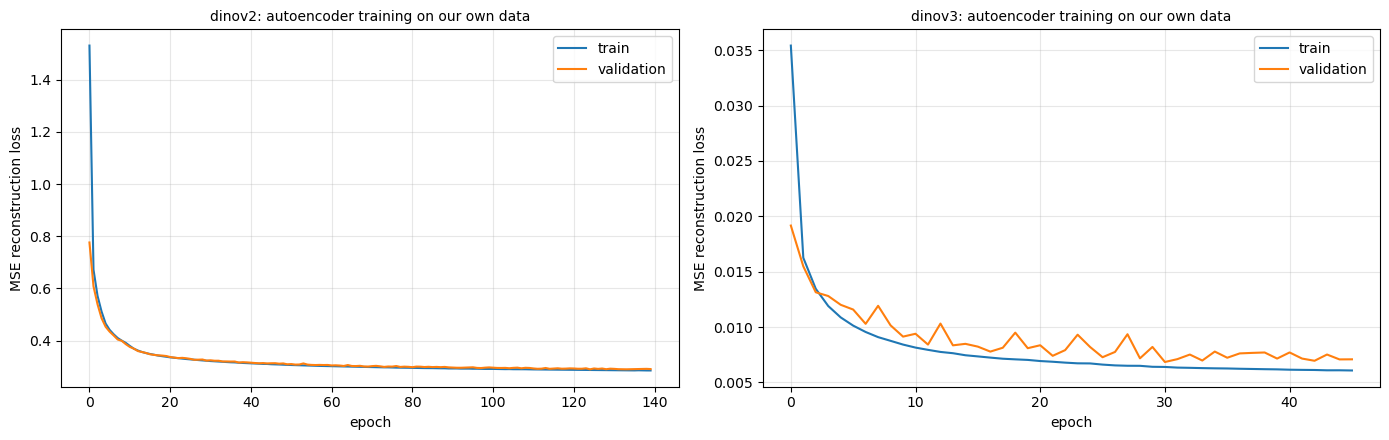

In [9]:
print(f"{'backbone':<10}{'patch':>7}{'grid':>7}{'vectors':>10}{'feat std':>11}{'best val MSE':>15}")
print('-' * 60)
for name, r in results.items():
    print(f"{name:<10}{r['patch']:>7}{r['grid']:>7}{r['n_vectors']:>10}"
          f"{r['feature_std']:>11.3f}{r['best_val_mse']:>15.5f}")

print('\nIMPORTANT: the two validation losses are NOT comparable with each other.')
print('DINOv3 feature values are numerically much smaller than DINOv2 ones (see "feat std"),')
print('so its reconstruction error is automatically smaller too. Each number only tells us')
print('that THAT model trained successfully.')

# loss curves
fig, axes = plt.subplots(1, len(results), figsize=(7 * len(results), 4.5))
if len(results) == 1:
    axes = [axes]
for ax, (name, r) in zip(axes, results.items()):
    ax.plot(r['train_losses'], label='train')
    ax.plot(r['val_losses'], label='validation')
    ax.set_title(f"{name}: autoencoder training on our own data", fontsize=10)
    ax.set_xlabel('epoch'); ax.set_ylabel('MSE reconstruction loss')
    ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'training_curves.png', dpi=120)
plt.show()

In [10]:
# how many training vectors came from each sequence?
print(f"{'sequence':<10}" + ''.join(f'{b:>12}' for b in BACKBONES))
print('-' * (10 + 12 * len(BACKBONES)))
for seq in SEQUENCES:
    row = ''
    for b in BACKBONES:
        f = FEAT_DIR / f'{b}_{seq}.npy'
        row += f'{len(np.load(f)):>12}' if f.is_file() else f"{'-':>12}"
    print(f'{seq:<10}' + row)

# save a small summary file next to the models
summary = {
    'note': 'STEPP-style autoencoders trained from scratch on our own Go2 dataset',
    'sequences_used': SEQUENCES,
    'sequences_excluded': EXCLUDE_SEQUENCES,
    'frames_skipped_at_start': SKIP_FIRST_FRAMES,
    'ground_offset_m': GROUND_OFFSET_M, 'robot_width_m': ROBOT_WIDTH_M,
    'future_steps': FUTURE_STEPS, 'min_move_m': MIN_MOVE_M,
    'architecture': HIDDEN_SIZES,
    'models': {name: {k: v for k, v in r.items() if k not in ('train_losses', 'val_losses')}
               for name, r in results.items()},
}
with open(MODEL_DIR / 'training_summary.json', 'w') as f:
    json.dump(summary, f, indent=2)
print('\nsaved ->', MODEL_DIR / 'training_summary.json')
print('models in', MODEL_DIR)
for p in sorted(MODEL_DIR.glob('*.pth')):
    print('   ', p.name)

sequence        dinov2      dinov3
----------------------------------
00003            10387       10361
00004            13893       13897
00005             5684        5673
00006            15883       15854
00007            23500       23522
00009            36740       36767
00010            33419       33449

saved -> s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\own_outputs\models\training_summary.json
models in s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\own_outputs\models
    own_autoencoder_dinov2.pth
    own_autoencoder_dinov3.pth


## 9. Sanity check: what do the models find familiar?

A quick look at one image. Because these models learned from our indoor/outdoor Go2 runs, the
floor and ground the robot walked on should get a **low** cost, while walls, furniture and
other obstacles should get a **high** cost.

checking on 00003 / frame000412-1786114068_245.jpg
dinov2: input 700, patch 14, feature grid 50x50
dinov3: input 704, patch 16, feature grid 44x44


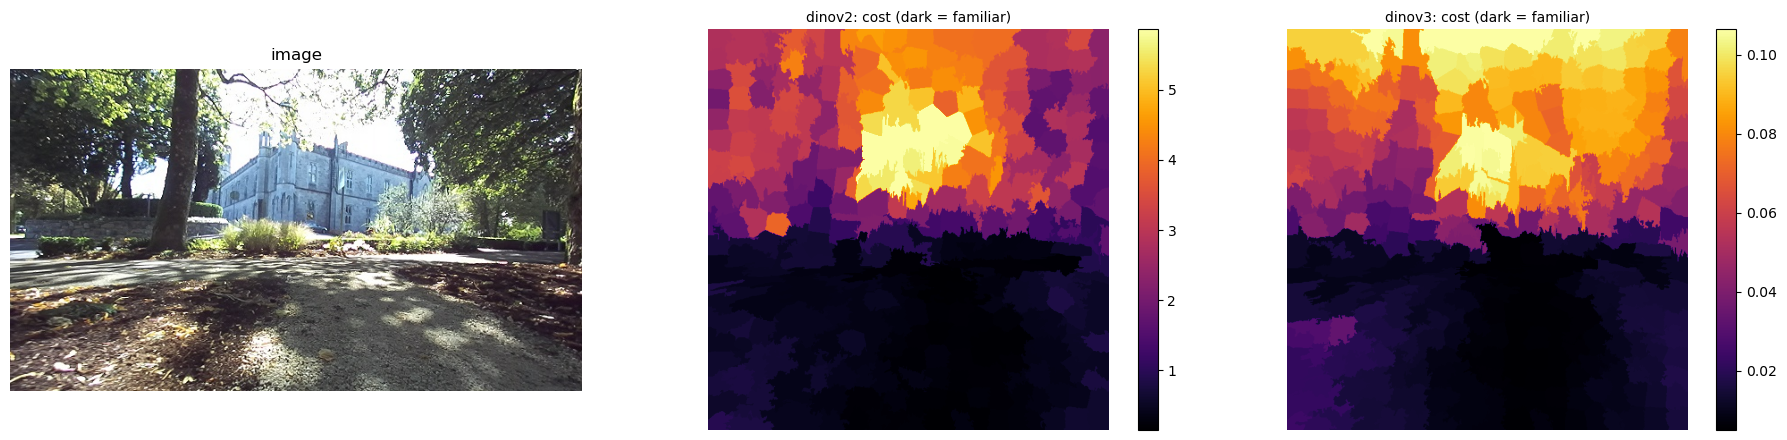

In [11]:
CHECK_SEQ = SEQUENCES[0]
check_data = sequence_data[CHECK_SEQ]
check_index = len(check_data['images']) // 2
check_image = check_data['images'][check_index]
print('checking on', CHECK_SEQ, '/', check_image.name)

fig, axes = plt.subplots(1, 1 + len(BACKBONES), figsize=(6 * (1 + len(BACKBONES)), 4.5))
bgr = cv2.imread(str(check_image))
axes[0].imshow(cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB))
axes[0].set_title('image'); axes[0].axis('off')

for ax, backbone_name in zip(axes[1:], BACKBONES):
    model, input_size, patch, grid = load_backbone(backbone_name)
    autoencoder = Autoencoder(384, HIDDEN_SIZES).to(device)
    autoencoder.load_state_dict(
        torch.load(MODEL_DIR / f'own_autoencoder_{backbone_name}.pth', map_location=device))
    autoencoder.eval()

    # cost for EVERY superpixel (not just path ones) -- this is inference
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    square = cv2.resize(rgb, (input_size, input_size))
    segments = slic(square, n_segments=N_SEGMENTS, compactness=COMPACTNESS,
                    start_label=0, channel_axis=-1)
    feature_map = get_feature_map(model, square, grid)
    small_segments = cv2.resize(segments.astype(np.int32), (grid, grid),
                                interpolation=cv2.INTER_NEAREST)

    ids, vectors = [], []
    for sid in np.unique(small_segments):
        cells = small_segments == sid
        if cells.sum() > 0:
            vectors.append(feature_map[cells].mean(axis=0)); ids.append(sid)
    vectors = np.array(vectors, dtype=np.float32)
    with torch.no_grad():
        x = torch.from_numpy(vectors).to(device)
        errors = ((x - autoencoder(x)) ** 2).mean(dim=1).cpu().numpy()

    cost_image = np.zeros((input_size, input_size), np.float32)
    for sid, err in zip(ids, errors):
        cost_image[segments == sid] = err

    im = ax.imshow(cost_image, cmap='inferno', vmax=np.percentile(errors, 97))
    ax.set_title(f'{backbone_name}: cost (dark = familiar)', fontsize=10); ax.axis('off')
    fig.colorbar(im, ax=ax, fraction=0.04)

    del model, autoencoder
    torch.cuda.empty_cache()

plt.tight_layout()
plt.savefig(MODEL_DIR / 'sanity_check.png', dpi=120)
plt.show()

---

## 10. What this notebook produced, and what it is for

### The two models

- `own_outputs/models/own_autoencoder_dinov2.pth`
- `own_outputs/models/own_autoencoder_dinov3.pth`

Both are STEPP-style encoder–decoder MLPs
(384 → 256 → 128 → 64 → **32** → 64 → 128 → 256 → 384) trained **from random weights** — the
STEPP authors' checkpoints were not used as a starting point. The only difference between the
two is which vision backbone produced the features.

### What they learned from

Only from **our own robot's driving experience**. No human labels were involved anywhere:
the training examples are the superpixels the Go2 actually walked over, found by projecting
each frame's next 50 poses back into the image.

### Which data went in

| Sequence | Used? | Reason |
|---|---|---|
| `00001` | no | test run only |
| `00003`–`00007` | yes | normal recordings |
| `00008` | no | robot barely moved (0.16 m over 38 frames) |
| `00009` | yes, minus the first 8 frames | odometry jumped while the robot stood still at the start |
| `00010` | yes | normal recording |

### Why the two validation losses must not be compared

DINOv3's feature numbers are much smaller in magnitude than DINOv2's. Since the loss is a mean
*squared* error over those numbers, DINOv3's loss is automatically far smaller — this says
nothing about which backbone is better. A fair comparison needs labelled data and
threshold-free metrics (ROC-AUC, average precision), which is what `comp_v2v3.ipynb` does on
RELLIS-3D.

### What comes next

Our own dataset has **no per-pixel semantic labels**, so these models cannot be scored on it.
The intended experiment is the reverse of the earlier work:

> **train on our own robot's data** (this notebook) **→ evaluate on RELLIS-3D**, where labels
> exist.

That is a strict cross-platform, cross-environment generalisation test: a Go2 quadruped's
experience being used to judge terrain recorded by a wheeled Warthog. To run it, load these
checkpoints into the evaluation code from `comp_v2v3.ipynb` (sections 5–6) instead of the
RELLIS-trained ones.

One honest caveat before drawing conclusions from that experiment: our recordings are mostly
indoor/short-range, while RELLIS is outdoor vegetation. If the transfer scores poorly, the most
likely reason is simply that the robot never experienced grass, mud or bushes — not that the
method fails. Outdoor Go2 sequences would make the comparison much fairer.

---

## 11. Evaluating our own-trained models on RELLIS-3D

Our own dataset has no per-pixel labels, so the two models above cannot be scored on the data
they learned from. RELLIS-3D **does** have labels, so we score them there instead.

This is the **cross-platform generalisation test**: a Unitree Go2's walking experience is used
to judge terrain recorded by a wheeled Warthog in a completely different environment. Note that
the models have never seen a single RELLIS image, so *every* RELLIS sequence is unseen data.
We use sequence `00002` so the numbers line up with the earlier `comp_v2v3.ipynb` experiment.

For context we also score the **RELLIS-trained** autoencoders from `comp_v2v3.ipynb` on exactly
the same pixels. That gives us four models to compare:

| Model | Trained on | Backbone |
|---|---|---|
| `own-dinov2` | our Go2 recordings | DINOv2 |
| `own-dinov3` | our Go2 recordings | DINOv3 |
| `rellis-dinov2` | RELLIS 00000/1/3/4 | DINOv2 |
| `rellis-dinov3` | RELLIS 00000/1/3/4 | DINOv3 |

The difference between an `own-*` and a `rellis-*` row is the price of the domain gap.

In [12]:
# ---- settings for the RELLIS evaluation ----
RELLIS_ROOT = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/Rellis_3D')
RELLIS_SEQ  = '00002'          # the sequence used as hold-out in comp_v2v3.ipynb
EVAL_EVERY  = 10               # use every Nth labelled frame (10 -> ~207 frames)
PIXELS_PER_FRAME = 6000        # random pixels sampled per frame, to keep memory small

# the RELLIS-trained autoencoders, for comparison
RELLIS_MODEL_DIR = Path('s:/#UNIVERSITY/Capstone/Code/Rellis_Stepp/outputs/comp_v2v3')

# RELLIS class id -> name
CLASS_NAMES = {0:'void', 1:'dirt', 3:'grass', 4:'tree', 5:'pole', 6:'water', 7:'sky',
               8:'vehicle', 9:'object', 10:'asphalt', 12:'building', 15:'log', 17:'person',
               18:'fence', 19:'bush', 23:'concrete', 27:'barrier', 31:'puddle', 33:'mud',
               34:'rubble'}
TRAVERSABLE_IDS = [1, 3, 10, 23, 31, 33]   # dirt, grass, asphalt, concrete, puddle, mud
IGNORE_IDS      = [0, 7]                    # void, sky

# which models to score: name -> (backbone, checkpoint file)
MODELS_TO_SCORE = {
    'own-dinov2'   : ('dinov2', MODEL_DIR / 'own_autoencoder_dinov2.pth'),
    'own-dinov3'   : ('dinov3', MODEL_DIR / 'own_autoencoder_dinov3.pth'),
    'rellis-dinov2': ('dinov2', RELLIS_MODEL_DIR / 'autoencoder_dinov2.pth'),
    'rellis-dinov3': ('dinov3', RELLIS_MODEL_DIR / 'autoencoder_dinov3.pth'),
}

# keep only the models whose checkpoint actually exists on disk
MODELS_TO_SCORE = {k: v for k, v in MODELS_TO_SCORE.items() if v[1].is_file()}
print('models that will be scored:')
for name, (backbone, ckpt) in MODELS_TO_SCORE.items():
    print(f'   {name:<15} backbone={backbone:<8} {ckpt.name}')

# find the RELLIS frames that have a label
rellis_images = sorted((RELLIS_ROOT / RELLIS_SEQ / 'pylon_camera_node').glob('*.jpg'))
rellis_labels_dir = RELLIS_ROOT / RELLIS_SEQ / 'pylon_camera_node_label_id'
eval_pairs = []
for image_path in rellis_images:
    label_path = rellis_labels_dir / (image_path.stem + '.png')
    if label_path.is_file():
        eval_pairs.append((image_path, label_path))
eval_pairs = eval_pairs[::EVAL_EVERY]
print(f'\nRELLIS {RELLIS_SEQ}: {len(eval_pairs)} labelled frames will be evaluated')

models that will be scored:
   own-dinov2      backbone=dinov2   own_autoencoder_dinov2.pth
   own-dinov3      backbone=dinov3   own_autoencoder_dinov3.pth
   rellis-dinov2   backbone=dinov2   autoencoder_dinov2.pth
   rellis-dinov3   backbone=dinov3   autoencoder_dinov3.pth

RELLIS 00002: 208 labelled frames will be evaluated


In [13]:
# ---- run every model over the RELLIS frames and record (cost, true class) per pixel ----

def cost_for_whole_image(model, input_size, grid, autoencoder, bgr):
    """Reconstruction cost for EVERY superpixel, resized back to the original image size."""
    height, width = bgr.shape[:2]
    rgb = cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)
    square = cv2.resize(rgb, (input_size, input_size))

    segments = slic(square, n_segments=N_SEGMENTS, compactness=COMPACTNESS,
                    start_label=0, channel_axis=-1)
    feature_map = get_feature_map(model, square, grid)
    small_segments = cv2.resize(segments.astype(np.int32), (grid, grid),
                                interpolation=cv2.INTER_NEAREST)

    ids, vectors = [], []
    for sid in np.unique(small_segments):
        cells = small_segments == sid
        if cells.sum() > 0:
            vectors.append(feature_map[cells].mean(axis=0)); ids.append(sid)
    vectors = np.array(vectors, dtype=np.float32)

    with torch.no_grad():
        x = torch.from_numpy(vectors).to(device)
        errors = ((x - autoencoder(x)) ** 2).mean(dim=1).cpu().numpy()

    cost_square = np.zeros((input_size, input_size), np.float32)
    for sid, err in zip(ids, errors):
        cost_square[segments == sid] = err
    return cv2.resize(cost_square, (width, height))

costs_by_model = {}     # model name -> long array of costs
pixel_classes = None    # the true RELLIS class of each sampled pixel (same for every model)

for model_name, (backbone_name, checkpoint) in MODELS_TO_SCORE.items():
    print(f'\n--- scoring {model_name} ---')
    model, input_size, patch, grid = load_backbone(backbone_name)
    autoencoder = Autoencoder(384, HIDDEN_SIZES).to(device)
    autoencoder.load_state_dict(torch.load(checkpoint, map_location=device))
    autoencoder.eval()

    frame_costs, frame_classes = [], []
    start = time.time()
    for frame_index, (image_path, label_path) in enumerate(eval_pairs):
        bgr = cv2.imread(str(image_path))
        label_image = cv2.imread(str(label_path), cv2.IMREAD_UNCHANGED)
        cost = cost_for_whole_image(model, input_size, grid, autoencoder, bgr)

        usable = ~np.isin(label_image, IGNORE_IDS)      # drop sky and void
        usable_costs = cost[usable]
        usable_classes = label_image[usable]

        # seed depends only on the frame number -> every model sees the SAME pixels
        rng = np.random.RandomState(frame_index)
        n_pick = min(PIXELS_PER_FRAME, len(usable_costs))
        pick = rng.choice(len(usable_costs), n_pick, replace=False)
        frame_costs.append(usable_costs[pick])
        frame_classes.append(usable_classes[pick])

        if frame_index % 50 == 0:
            print(f'    frame {frame_index}/{len(eval_pairs)}')

    costs_by_model[model_name] = np.concatenate(frame_costs)
    if pixel_classes is None:
        pixel_classes = np.concatenate(frame_classes)
    print(f'    done in {time.time() - start:.0f}s')

    del model, autoencoder
    torch.cuda.empty_cache()

present_classes = sorted(np.unique(pixel_classes).tolist())
print(f'\ntotal sampled pixels: {len(pixel_classes):,}')
print('classes present:', [f'{c} ({CLASS_NAMES.get(c, "?")})' for c in present_classes])


--- scoring own-dinov2 ---
dinov2: input 700, patch 14, feature grid 50x50
    frame 0/208
    frame 50/208
    frame 100/208
    frame 150/208
    frame 200/208
    done in 121s

--- scoring own-dinov3 ---
dinov3: input 704, patch 16, feature grid 44x44
    frame 0/208
    frame 50/208
    frame 100/208
    frame 150/208
    frame 200/208
    done in 113s

--- scoring rellis-dinov2 ---
dinov2: input 700, patch 14, feature grid 50x50
    frame 0/208
    frame 50/208
    frame 100/208
    frame 150/208
    frame 200/208
    done in 115s

--- scoring rellis-dinov3 ---
dinov3: input 704, patch 16, feature grid 44x44
    frame 0/208
    frame 50/208
    frame 100/208
    frame 150/208
    frame 200/208
    done in 115s

total sampled pixels: 1,248,000
classes present: ['3 (grass)', '4 (tree)', '5 (pole)', '6 (water)', '8 (vehicle)', '9 (object)', '10 (asphalt)', '12 (building)', '17 (person)', '19 (bush)', '23 (concrete)', '27 (barrier)', '31 (puddle)', '33 (mud)']


In [14]:
# ---- overall scores ----
from sklearn.metrics import roc_auc_score, average_precision_score

def iou_at(costs, labels, threshold):
    """IoU of the traversable class when 'traversable' means cost below the threshold."""
    predicted = costs < threshold
    tp = np.sum(predicted & (labels == 1))
    fp = np.sum(predicted & (labels == 0))
    fn = np.sum(~predicted & (labels == 1))
    union = tp + fp + fn
    return tp / union if union > 0 else 0.0

def score_model(costs, labels):
    """labels: 1 = traversable, 0 = obstacle. Low cost should mean traversable."""
    roc_auc = roc_auc_score(labels, -costs)          # higher score = more traversable
    ap = average_precision_score(labels, -costs)

    # Sweep thresholds at QUANTILES of the observed costs, not on a fixed grid.
    # The four models live on very different cost scales, so a fixed grid would be unfair.
    best_iou, best_threshold = 0.0, 0.0
    for threshold in np.quantile(costs, np.linspace(0.01, 0.99, 199)):
        value = iou_at(costs, labels, threshold)
        if value > best_iou:
            best_iou, best_threshold = value, float(threshold)
    return {'roc_auc': float(roc_auc), 'ap': float(ap),
            'best_iou': float(best_iou), 'best_threshold': best_threshold}

binary_labels = np.isin(pixel_classes, TRAVERSABLE_IDS).astype(int)
print(f'traversable share of the evaluated pixels: {100 * binary_labels.mean():.1f}%\n')

rellis_scores = {}
print(f"{'model':<16}{'ROC-AUC':>10}{'AP':>9}{'best IoU':>11}{'@threshold':>14}")
print('-' * 60)
for model_name, costs in costs_by_model.items():
    rellis_scores[model_name] = score_model(costs, binary_labels)
    s = rellis_scores[model_name]
    print(f"{model_name:<16}{s['roc_auc']:>10.3f}{s['ap']:>9.3f}"
          f"{s['best_iou']:>11.3f}{s['best_threshold']:>14.4g}")

print()
print('The "@threshold" column is in each model own cost units and is NOT comparable')
print('across rows. ROC-AUC, AP and best IoU are comparable.')

traversable share of the evaluated pixels: 55.5%

model              ROC-AUC       AP   best IoU    @threshold
------------------------------------------------------------
own-dinov2           0.890    0.899      0.721         3.059
own-dinov3           0.901    0.912      0.743       0.06096
rellis-dinov2        0.817    0.859      0.642         1.624
rellis-dinov3        0.815    0.849      0.646       0.04099

The "@threshold" column is in each model own cost units and is NOT comparable
across rows. ROC-AUC, AP and best IoU are comparable.


class         pixels      own-dinov2      own-dinov3   rellis-dinov2   rellis-dinov3
------------------------------------------------------------------------------------
grass*        610047           94.0%           95.5%           90.3%           92.5%
tree          111671           14.1%           13.2%            0.0%            0.1%
pole             989           36.4%           31.0%            0.0%            0.2%
water           3129           12.6%            2.4%           73.4%           83.6%
vehicle         1394           57.1%           68.8%            0.0%            0.6%
object          1217           64.8%           51.8%            0.0%            0.2%
asphalt*        3245           86.5%           61.8%            0.0%            0.7%
building         597           56.6%           71.9%            0.0%            1.0%
person           303            5.9%           41.9%            0.0%            2.3%
bush          432741           36.8%           30.5%           38

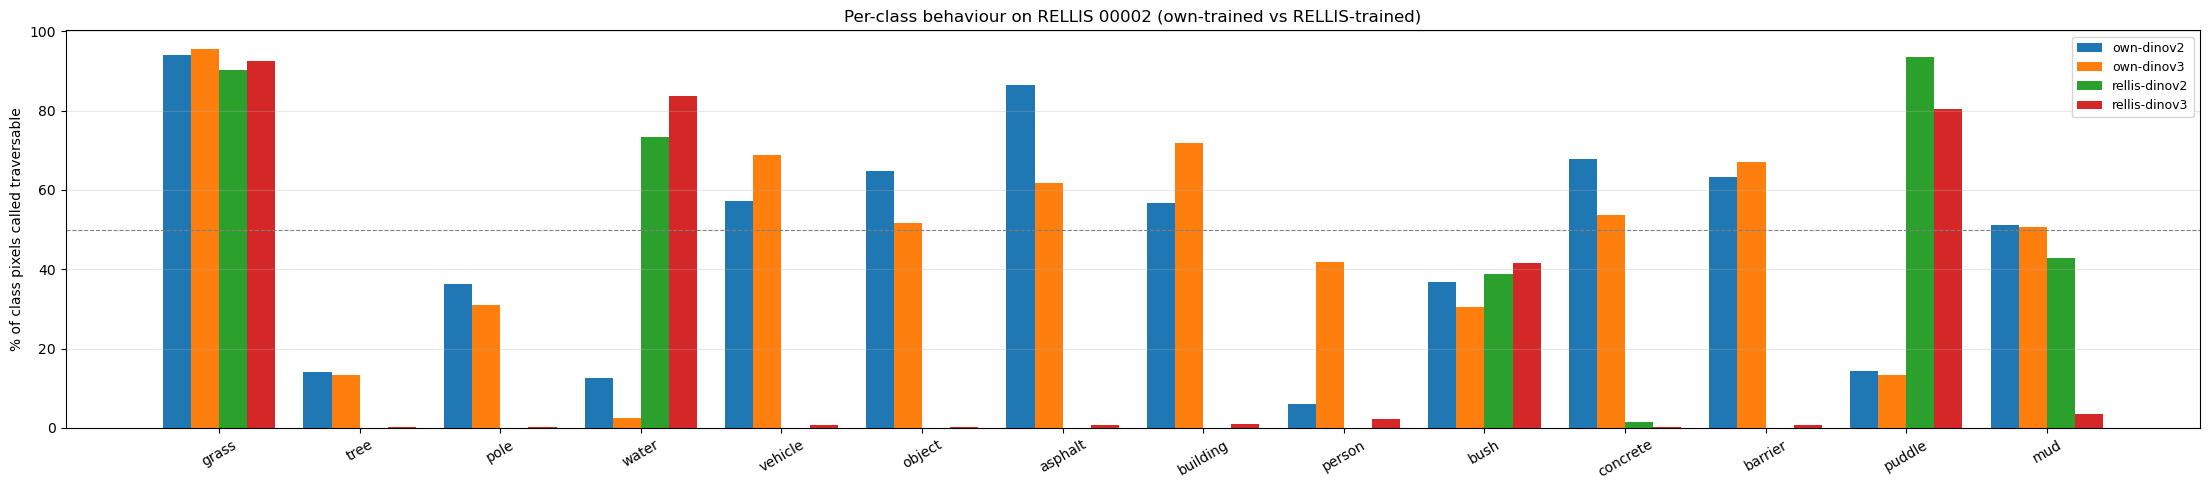

In [15]:
# ---- per-class behaviour: what fraction of each RELLIS class is called traversable? ----
percent_traversable = {name: {} for name in costs_by_model}

header = f"{'class':<11}{'pixels':>9}"
for name in costs_by_model:
    header += f'{name:>16}'
print(header)
print('-' * len(header))

for class_id in present_classes:
    mask = pixel_classes == class_id
    class_name = CLASS_NAMES.get(class_id, f'id {class_id}')
    marker = '*' if class_id in TRAVERSABLE_IDS else ' '
    line = f'{class_name + marker:<11}{mask.sum():>9}'
    for name, costs in costs_by_model.items():
        threshold = rellis_scores[name]['best_threshold']
        pct = 100.0 * np.mean(costs[mask] < threshold)
        percent_traversable[name][class_id] = pct
        line += f'{pct:>15.1f}%'
    print(line)

print()
print('* = labelled traversable in RELLIS. For those rows a HIGH number is correct;')
print('  for every other row a LOW number is correct.')

# ---- bar chart ----
class_labels = [CLASS_NAMES.get(c, str(c)) for c in present_classes]
x = np.arange(len(present_classes))
width = 0.8 / len(costs_by_model)

plt.figure(figsize=(1.3 * len(present_classes) + 4, 5))
for i, name in enumerate(costs_by_model):
    values = [percent_traversable[name][c] for c in present_classes]
    plt.bar(x + i * width, values, width, label=name)
plt.xticks(x + width * (len(costs_by_model) - 1) / 2, class_labels, rotation=30)
plt.ylabel('% of class pixels called traversable')
plt.title(f'Per-class behaviour on RELLIS {RELLIS_SEQ} (own-trained vs RELLIS-trained)')
plt.axhline(50, color='gray', linestyle='--', linewidth=0.8)
plt.legend(fontsize=9)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'rellis_per_class.png', dpi=120)
plt.show()

scenario                    model              ROC-AUC       AP   best IoU
--------------------------------------------------------------------------
default (mud+puddle trav.)  own-dinov2           0.890    0.899      0.721
default (mud+puddle trav.)  own-dinov3           0.901    0.912      0.743
default (mud+puddle trav.)  rellis-dinov2        0.817    0.859      0.642
default (mud+puddle trav.)  rellis-dinov3        0.815    0.849      0.646

strict (mud+puddle obst.)   own-dinov2           0.890    0.899      0.721
strict (mud+puddle obst.)   own-dinov3           0.901    0.912      0.742
strict (mud+puddle obst.)   rellis-dinov2        0.818    0.859      0.641
strict (mud+puddle obst.)   rellis-dinov3        0.817    0.849      0.647

pavement -> obstacle        own-dinov2           0.899    0.889      0.695
pavement -> obstacle        own-dinov3           0.926    0.915      0.738
pavement -> obstacle        rellis-dinov2        0.900    0.889      0.706
pavement -> obstacle   

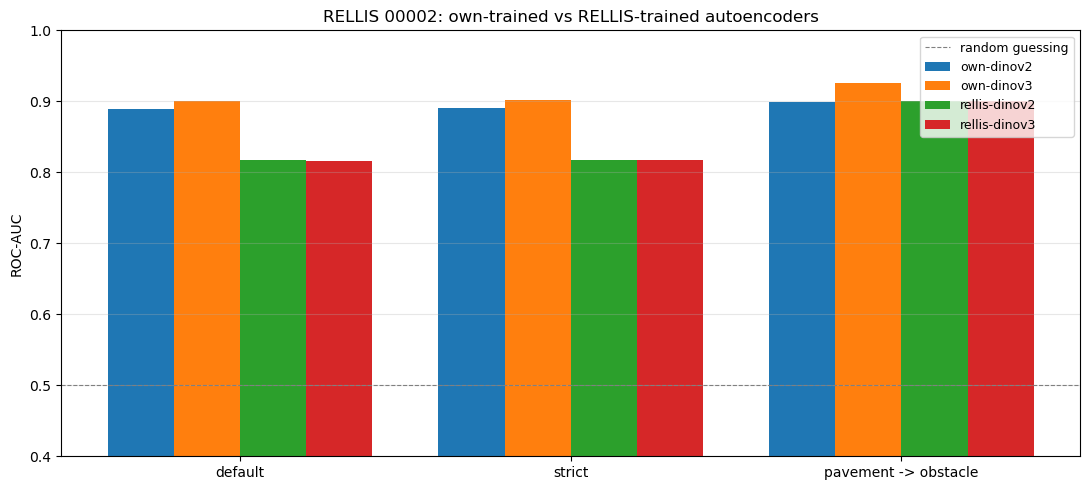

saved -> s:\#UNIVERSITY\Capstone\Code\Rellis_Stepp\own_outputs\models\rellis_evaluation.json


In [16]:
# ---- does the label choice change the picture? (same idea as comp_v2v3 section 14) ----
SCENARIOS = {
    'default (mud+puddle trav.)': [1, 3, 10, 23, 33, 31],
    'strict (mud+puddle obst.)' : [1, 3, 10, 23],
    'pavement -> obstacle'      : [1, 3, 33, 31],
}

print(f"{'scenario':<28}{'model':<16}{'ROC-AUC':>10}{'AP':>9}{'best IoU':>11}")
print('-' * 74)
scenario_scores = {}
for scenario_name, traversable_ids in SCENARIOS.items():
    labels = np.isin(pixel_classes, traversable_ids).astype(int)
    for model_name, costs in costs_by_model.items():
        s = score_model(costs, labels)
        scenario_scores[(scenario_name, model_name)] = s
        print(f"{scenario_name:<28}{model_name:<16}{s['roc_auc']:>10.3f}"
              f"{s['ap']:>9.3f}{s['best_iou']:>11.3f}")
    print()

# ---- summary chart ----
scenario_names = list(SCENARIOS.keys())
x = np.arange(len(scenario_names))
width = 0.8 / len(costs_by_model)
plt.figure(figsize=(11, 5))
for i, name in enumerate(costs_by_model):
    values = [scenario_scores[(s, name)]['roc_auc'] for s in scenario_names]
    plt.bar(x + i * width, values, width, label=name)
plt.xticks(x + width * (len(costs_by_model) - 1) / 2,
           [s.split('(')[0].strip() for s in scenario_names])
plt.ylabel('ROC-AUC'); plt.ylim(0.4, 1.0)
plt.axhline(0.5, color='gray', linestyle='--', linewidth=0.8, label='random guessing')
plt.title(f'RELLIS {RELLIS_SEQ}: own-trained vs RELLIS-trained autoencoders')
plt.legend(fontsize=9); plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig(MODEL_DIR / 'rellis_scenarios.png', dpi=120)
plt.show()

# ---- save everything ----
evaluation_summary = {
    'note': 'own-dataset-trained autoencoders evaluated on RELLIS-3D (never seen in training)',
    'rellis_sequence': RELLIS_SEQ,
    'frames_evaluated': len(eval_pairs),
    'pixels_sampled': int(len(pixel_classes)),
    'traversable_share': float(binary_labels.mean()),
    'overall': rellis_scores,
    'per_class_percent_traversable': {
        name: {CLASS_NAMES.get(c, str(c)): round(percent_traversable[name][c], 2)
               for c in present_classes}
        for name in costs_by_model},
    'scenarios': {f'{s} | {m}': v for (s, m), v in scenario_scores.items()},
}
with open(MODEL_DIR / 'rellis_evaluation.json', 'w') as f:
    json.dump(evaluation_summary, f, indent=2)
print('saved ->', MODEL_DIR / 'rellis_evaluation.json')

## 12. How to read these results

**What this measures.** The `own-*` models learned only from a Go2 walking around our own
environment and have never seen a RELLIS image. Scoring them on RELLIS therefore measures pure
cross-platform, cross-environment transfer. The `rellis-*` rows are the same architecture
trained on RELLIS itself, so the gap between the two is the cost of the domain shift.

**Which numbers to trust.** ROC-AUC, AP and best-IoU are comparable across all four models.
The cost thresholds are *not*: each model has its own cost scale (DINOv3 features are
numerically much smaller than DINOv2 features, and models trained on different data settle at
different magnitudes). This is exactly why the threshold sweep uses quantiles of each model's
own costs instead of a fixed grid.

**What a low score would mean.** If the `own-*` models score near 0.5 ROC-AUC, the honest
reading is *not* that the method failed, but that our recordings simply do not contain the
terrain RELLIS is made of. Our robot mostly walked on indoor floors and short outdoor stretches;
RELLIS is grass, mud, bushes and trees. An autoencoder can only call terrain "familiar" if it
has seen something like it. The per-class table shows this directly: look at whether grass and
dirt (the classes RELLIS is dominated by) are recognised at all.

**What a high score would mean.** If the `own-*` models come close to the `rellis-*` ones, it
would be strong evidence that DINOv2/DINOv3 features encode a notion of "walkable ground" that
is general enough to survive a change of robot, camera and environment - which is the central
claim this project set out to test.

**Fair-comparison caveat.** The `rellis-*` models were trained on RELLIS sequences 00000, 00001,
00003 and 00004 and are evaluated here on 00002, which they never saw either. So both sides are
evaluated on unseen data; the only difference is the *training domain*, which is what we want to
isolate.